# 用 PyTorch 從零實作簡單大語言模型（LLM）

本筆記本使用 **PyTorch** 實作一個完整的字元級 Transformer 語言模型。

相較於純 Python 版本，PyTorch 版本帶來：
- ✅ **自動微分**（autograd）：不需手動計算梯度
- ✅ **GPU 加速**：一行切換 CPU/GPU
- ✅ **真正的反向傳播**：訓練速度快上百倍
- ✅ **內建最佳化器**：Adam、SGD 等

架構：**GPT 風格的 Decoder-only Transformer**

## 1. 安裝與匯入

In [ ]:
# 若尚未安裝：
# !pip install torch

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random

# 裝置選擇（自動偵測 GPU）
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用裝置:     {device}")

PyTorch 版本: 2.11.0
使用裝置:     cpu


## 2. 超參數設定

In [ ]:
# ── 模型超參數 ──────────────────────────────────────
VOCAB_SIZE = 65  # 字元詞彙表大小（稍後動態計算）
D_MODEL = 64  # 隱藏層維度
N_HEADS = 4  # 注意力頭數
N_LAYERS = 2  # Transformer Block 層數
D_FF = 256  # Feed Forward 中間層維度
SEQ_LEN = 32  # 最大序列長度（context window）
DROPOUT = 0.1  # Dropout 比率

# ── 訓練超參數 ──────────────────────────────────────
BATCH_SIZE = 16  # 每批次樣本數
LR = 3e-4  # 學習率（Adam）
N_EPOCHS = 200  # 訓練輪數
EVAL_EVERY = 20  # 每幾步顯示損失

print("超參數設定完成 ✓")

超參數設定完成 ✓


## 3. 資料準備：字元級 Tokenizer

In [ ]:
# 訓練文字（可替換成任何文字）
TEXT = """
to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
or to take arms against a sea of troubles
and by opposing end them to die to sleep
no more and by a sleep to say we end
the heartache and the thousand natural shocks
that flesh is heir to tis a consummation
devoutly to be wished to die to sleep
to sleep perchance to dream ay there is the rub
""".strip()

# 建立字元詞彙表
chars = sorted(set(TEXT))
VOCAB_SIZE = len(chars)
char2id = {c: i for i, c in enumerate(chars)}
id2char = {i: c for c, i in char2id.items()}


def encode(text):
    return [char2id[c] for c in text if c in char2id]


def decode(ids):
    return "".join(id2char[i] for i in ids)


data = torch.tensor(encode(TEXT), dtype=torch.long)

print(f"文字長度:      {len(TEXT)} 字元")
print(f"詞彙表大小:    {VOCAB_SIZE}")
print(f"字元範例:      {chars}")
print(f"資料 tensor:   shape={data.shape}, dtype={data.dtype}")

文字長度:      417 字元
詞彙表大小:    25
字元範例:      ['\n', ' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y']
資料 tensor:   shape=torch.Size([417]), dtype=torch.int64


## 4. 批次資料生成器

In [ ]:
def get_batch(data, batch_size, seq_len):
    """
    隨機取樣 batch_size 個長度為 seq_len 的序列
    x: 輸入序列  [batch_size, seq_len]
    y: 目標序列  [batch_size, seq_len]（x 右移一位）
    """
    n = len(data) - seq_len - 1
    starts = torch.randint(0, n, (batch_size,))
    x = torch.stack([data[s : s + seq_len] for s in starts])
    y = torch.stack([data[s + 1 : s + seq_len + 1] for s in starts])
    return x.to(device), y.to(device)


# 示範
xb, yb = get_batch(data, batch_size=2, seq_len=SEQ_LEN)
print(f"輸入 x: shape={xb.shape}")
print(f"目標 y: shape={yb.shape}")
print(f"輸入範例: '{decode(xb[0].tolist())}'")
print(f"目標範例: '{decode(yb[0].tolist())}' （同上右移一位）")

輸入 x: shape=torch.Size([2, 32])
目標 y: shape=torch.Size([2, 32])
輸入範例: 'obler in the mind to suffer
the '
目標範例: 'bler in the mind to suffer
the s' （同上右移一位）


## 5. Multi-Head Self-Attention

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

多頭版本將 d_model 分成 n_heads 個子空間，平行計算後串接。

In [ ]:
class MultiHeadAttention(nn.Module):
    """
    多頭因果自注意力
    - 每頭維度 d_head = d_model // n_heads
    - 使用 causal mask 確保只看過去
    """

    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        # Q, K, V 投影（合併成一個大矩陣效率更高）
        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape  # batch, seq_len, d_model

        # 計算 Q, K, V
        qkv = self.qkv_proj(x)  # [B, T, 3C]
        Q, K, V = qkv.split(C, dim=-1)  # 各 [B, T, C]

        # 拆成多頭：[B, T, C] → [B, n_heads, T, d_head]
        def split_heads(t):
            return t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

        # 注意力分數並套用 Causal Mask
        scale = math.sqrt(self.d_head)
        scores = (Q @ K.transpose(-2, -1)) / scale  # [B, H, T, T]

        # 建立因果 mask（上三角設為 -inf）
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)  # [B, H, T, T]
        attn = self.dropout(attn)

        # 加權求和 V
        out = attn @ V  # [B, H, T, d_head]

        # 合併多頭：[B, H, T, d_head] → [B, T, C]
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


print("MultiHeadAttention 定義完成 ✓")

MultiHeadAttention 定義完成 ✓


## 6. Feed Forward Network

In [ ]:
class FeedForward(nn.Module):
    """
    Position-wise FFN：Linear → GELU → Linear → Dropout
    使用 GELU 而非 ReLU（GPT-2 風格）
    """

    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


print("FeedForward 定義完成 ✓")

FeedForward 定義完成 ✓


## 7. Transformer Block

使用 **Pre-LayerNorm**（更穩定的訓練，GPT-2 以後標準做法）：
$$x = x + \text{Attn}(\text{LayerNorm}(x))$$
$$x = x + \text{FFN}(\text{LayerNorm}(x))$$

In [ ]:
class TransformerBlock(nn.Module):
    """Pre-LayerNorm Transformer Block"""

    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))  # 殘差 + Attention
        x = x + self.ff(self.ln2(x))  # 殘差 + FFN
        return x


print("TransformerBlock 定義完成 ✓")

TransformerBlock 定義完成 ✓


## 8. 完整 GPT 風格語言模型

In [ ]:
class MiniGPT(nn.Module):
    """
    GPT 風格 Decoder-only Transformer
    架構：TokenEmb + PosEmb → N × TransformerBlock → LayerNorm → Linear
    """

    def __init__(
        self, vocab_size, d_model, n_heads, n_layers, d_ff, seq_len, dropout=0.0
    ):
        super().__init__()
        self.seq_len = seq_len

        # Embedding：Token + Position（可學習）
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)  # 可學習 vs sin/cos
        self.drop = nn.Dropout(dropout)

        # Transformer Blocks
        self.blocks = nn.Sequential(
            *[
                TransformerBlock(d_model, n_heads, d_ff, dropout)
                for _ in range(n_layers)
            ]
        )

        # 最後的 LayerNorm 和輸出投影
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        # 權重共享：輸入 Embedding 與輸出矩陣共用（GPT-2 技巧）
        self.head.weight = self.token_emb.weight

        # 初始化權重
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        idx:     [B, T]  輸入 Token IDs
        targets: [B, T]  目標 Token IDs（訓練時傳入，推論時為 None）
        回傳: (logits, loss)  loss 在推論時為 None
        """
        B, T = idx.shape
        assert T <= self.seq_len, f"序列長度 {T} 超過最大值 {self.seq_len}"

        # Token Embedding + Positional Embedding
        tok = self.token_emb(idx)  # [B, T, D]
        pos = self.pos_emb(torch.arange(T, device=idx.device))  # [T, D]
        x = self.drop(tok + pos)  # [B, T, D]

        # Transformer Blocks
        x = self.blocks(x)  # [B, T, D]
        x = self.ln_final(x)  # [B, T, D]

        # 輸出投影
        logits = self.head(x)  # [B, T, vocab_size]

        # 計算損失（訓練模式）
        loss = None
        if targets is not None:
            # reshape 為 [B*T, vocab_size] 和 [B*T]
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# 建立模型
torch.manual_seed(42)
model = MiniGPT(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    seq_len=SEQ_LEN,
    dropout=DROPOUT,
).to(device)

print(f"模型建立完成 ✓")
print(f"總參數量: {model.count_params():,}")
print(f"\n模型結構:")
print(model)

模型建立完成 ✓
總參數量: 103,232

模型結構:
MiniGPT(
  (token_emb): Embedding(25, 64)
  (pos_emb): Embedding(32, 64)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (qkv_proj): Linear(in_features=64, out_features=192, bias=False)
        (out_proj): Linear(in_features=64, out_features=64, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=256, out_features=64, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (1): TransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (qkv_pro

## 9. 訓練迴圈

In [ ]:
# Adam 最佳化器（LLM 訓練標準選擇）
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 學習率排程：CosineAnnealingLR（訓練後期降低 LR）
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

losses = []
model.train()

print(f"開始訓練：{N_EPOCHS} epochs, batch_size={BATCH_SIZE}\n")
print(f"{'Epoch':>6}  {'Loss':>8}  {'LR':>10}")
print("-" * 30)

for epoch in range(1, N_EPOCHS + 1):
    # 取得批次資料
    xb, yb = get_batch(data, BATCH_SIZE, SEQ_LEN)

    # 前向傳播
    logits, loss = model(xb, yb)

    # 反向傳播
    optimizer.zero_grad()  # 清除上一步的梯度
    loss.backward()  # 自動計算所有梯度（autograd）

    # 梯度裁剪（防止梯度爆炸）
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()  # 更新參數
    scheduler.step()  # 更新學習率

    losses.append(loss.item())

    if epoch % EVAL_EVERY == 0 or epoch == 1:
        current_lr = scheduler.get_last_lr()[0]
        print(f"{epoch:>6}  {loss.item():>8.4f}  {current_lr:>10.2e}")

print(f"\n訓練完成！最終損失: {losses[-1]:.4f}")

開始訓練：200 epochs, batch_size=16

 Epoch      Loss          LR
------------------------------
     1    3.2376    3.00e-04
    20    2.8404    2.93e-04
    40    2.6559    2.71e-04
    60    2.4974    2.38e-04
    80    2.4564    1.96e-04
   100    2.3057    1.50e-04
   120    2.2557    1.04e-04
   140    2.2753    6.18e-05
   160    2.2925    2.86e-05
   180    2.2321    7.34e-06
   200    2.2178    0.00e+00

訓練完成！最終損失: 2.2178


## 10. 損失曲線視覺化

/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_3061/2272556455.py:17: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_3061/2272556455.py:17: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_3061/2272556455.py:17: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_3061/2272556455.py:17: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_3061/2272556455.py:17: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10

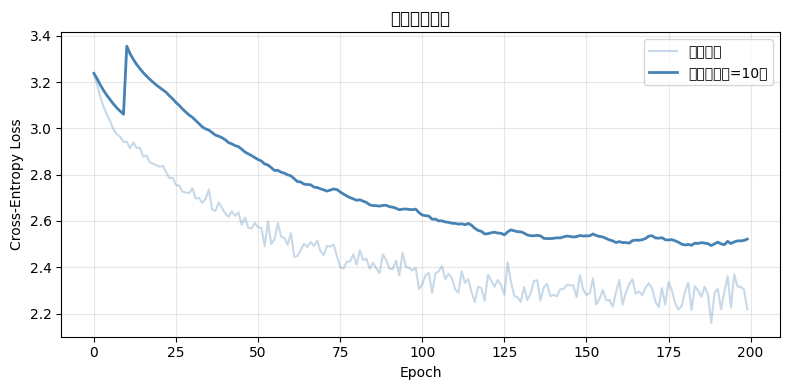

起始損失: 3.2376  →  最終損失: 2.2178


In [ ]:
try:
    import matplotlib.pyplot as plt

    # 平滑損失曲線（移動平均）
    window = 10
    smooth = [
        sum(losses[max(0, i - window) : i + 1]) / min(i + 1, window)
        for i in range(len(losses))
    ]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(losses, alpha=0.3, color="steelblue", label="原始損失")
    ax.plot(smooth, color="steelblue", linewidth=2, label=f"平滑（窗口={window}）")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title("訓練損失曲線")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"起始損失: {losses[0]:.4f}  →  最終損失: {losses[-1]:.4f}")

except ImportError:
    print("matplotlib 未安裝，改用文字圖表：")
    step = max(1, len(losses) // 20)
    for i in range(0, len(losses), step):
        bar = "█" * int(losses[i] * 5)
        print(f"Epoch {i+1:3d}: {losses[i]:.4f}  {bar}")

## 11. 文字生成（Inference）

In [ ]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=100, temperature=1.0, top_k=None):
    """
    自回歸文字生成

    參數：
      prompt        - 起始文字
      max_new_tokens - 最多生成幾個 token
      temperature   - >1 更隨機，<1 更確定；0 = greedy
      top_k         - 只從前 k 個機率最高的 token 中採樣
    """
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        # 截斷到 seq_len
        ctx = ids[:, -model.seq_len :]
        logits, _ = model(ctx)
        logits = logits[:, -1, :]  # 取最後位置 [1, vocab_size]

        if temperature == 0:
            # Greedy decoding
            next_id = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k is not None:
                # Top-k 過濾
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        ids = torch.cat([ids, next_id], dim=1)

    return decode(ids[0].tolist())


# ── 不同溫度的生成效果 ──────────────────────────────
prompt = "to be"
print(f"Prompt: '{prompt}'\n")
print("=" * 55)

configs = [
    (0, None, "Greedy（最確定）"),
    (0.5, 10, "低溫 + Top-k=10"),
    (1.0, 20, "標準溫度 + Top-k=20"),
    (1.5, None, "高溫（最有創意）"),
]

for temp, k, label in configs:
    result = generate(model, prompt, max_new_tokens=60, temperature=temp, top_k=k)
    print(f"\n[{label}]")
    print(result)
    print("-" * 55)

Prompt: 'to be'


[Greedy（最確定）]
to be the the the the the the the the the the the the the the the
-------------------------------------------------------

[低溫 + Top-k=10]
to be tond the ie to to to the tore the tis s de to s
the tho to 
-------------------------------------------------------

[標準溫度 + Top-k=20]
to be dsemohsa bnge f tp anskar
n
mpvvro s
htndio shleis hq hemwn
-------------------------------------------------------

[高溫（最有創意）]
to bevrftaskaulcatorayd ycrndri ippsotrrde dldunt
acynhtornraevd 
-------------------------------------------------------


## 12. 儲存與載入模型

In [ ]:
# 儲存模型
torch.save(
    {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "char2id": char2id,
        "id2char": id2char,
        "config": {
            "vocab_size": VOCAB_SIZE,
            "d_model": D_MODEL,
            "n_heads": N_HEADS,
            "n_layers": N_LAYERS,
            "d_ff": D_FF,
            "seq_len": SEQ_LEN,
        },
    },
    "mini_gpt.pt",
)
print("模型已儲存至 mini_gpt.pt ✓")


# 載入模型
checkpoint = torch.load("mini_gpt.pt", map_location=device)
cfg = checkpoint["config"]

loaded_model = MiniGPT(**cfg, dropout=0.0).to(device)
loaded_model.load_state_dict(checkpoint["model_state"])
loaded_model.eval()
print("模型載入成功 ✓")

# 驗證載入後生成結果一致
torch.manual_seed(0)
result = generate(loaded_model, "to", max_new_tokens=30, temperature=0.8)
print(f"載入後生成: '{result}'")

模型已儲存至 mini_gpt.pt ✓
模型載入成功 ✓
載入後生成: 'to tg o thes tg s aknge sano yib'


## 13. 純 Python vs PyTorch 對比總結

| 面向 | 純 Python 版 | PyTorch 版 |
|------|------------|------------|
| 梯度計算 | 數值微分（慢，O(參數量)）| `loss.backward()` 自動微分 |
| 矩陣運算 | 三重 for 迴圈 | BLAS/CUDA 最佳化 |
| GPU 支援 | ❌ | ✅ `.to(device)` 一行切換 |
| 批次訓練 | ❌ | ✅ 原生支援 |
| 最佳化器 | 手刻 SGD | Adam、AdamW 等開箱即用 |
| 訓練速度 | 極慢（示範用）| 快上百～千倍 |
| 程式碼量 | 多（每個算子都手寫）| 少（高層抽象）|
| 學習價值 | 理解底層原理 | 接近生產環境實踐 |

**下一步建議：**
- 🔗 [nanoGPT](https://github.com/karpathy/nanoGPT)：更完整的 GPT 實作
- 📦 [Hugging Face Transformers](https://github.com/huggingface/transformers)：載入預訓練模型
- 📖 嘗試把訓練資料換成中文文字，觀察模型是否能學會字元規律